In [ ]:
import pandas as pd

In [ ]:
names = ['place', 'age', 'NoMale', 'NoFemale', 'DNoMale', 'DNoFemale']

In [ ]:
dataset = pd.read_csv('data.csv', names=names)

In [ ]:
print(dataset.shape)

(216, 6)


In [ ]:
print(dataset.describe())

             NoMale      NoFemale      DNoMale    DNoFemale
count    216.000000    216.000000   216.000000   216.000000
mean    2197.353102   2184.069815   180.928241   114.643102
std     2963.186406   3020.554729   563.541448   418.280949
min        0.810000      0.730000     0.000000     0.000000
25%      160.455000    159.192500     0.350000     0.160000
50%     1768.305000   1671.160000     4.800000     2.690000
75%     3289.440000   3240.902500    71.752500    28.575000
max    35710.210000  36253.800000  4977.920000  3835.830000


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, probplot

In [ ]:
SData = dataset.groupby('place')[['NoMale', 'NoFemale', 'DNoMale', 'DNoFemale']].sum().reset_index()

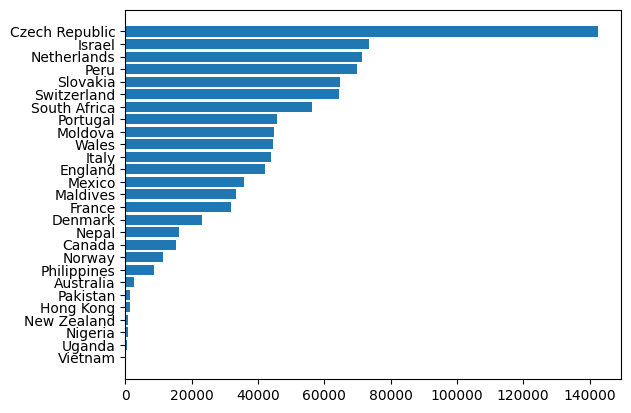

In [ ]:
SData['TotalCases'] = SData['NoMale'] + SData['NoFemale']
SData_sorted = SData.sort_values('TotalCases')
plt.barh(SData_sorted['place'], SData_sorted['TotalCases'])
plt.show()

In [ ]:
SData['PropMale'] = SData['NoMale'] / (SData['NoMale'] + SData['NoFemale'])
print("Mean:", SData['PropMale'].mean())
print("Std:", SData['PropMale'].std())

Mean: 0.5258118325612873
Std: 0.06731663922927228


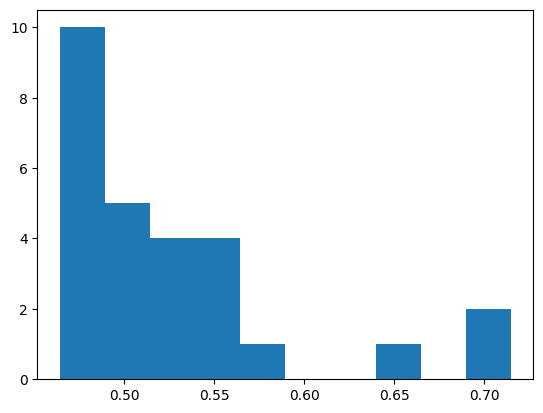

In [ ]:
plt.hist(SData['PropMale'], bins=10)
plt.show()

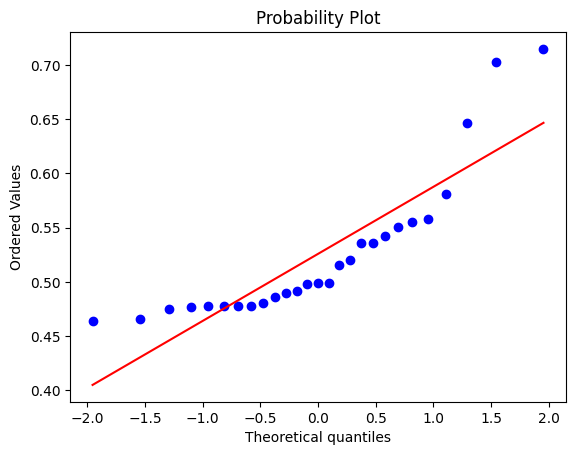

In [ ]:
probplot(SData['PropMale'], dist="norm", plot=plt)
plt.show()

/tmp/ipython-input-305/3566396455.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([SData['PropMale'], 1 - SData['PropMale']], labels=['Male', 'Female'])


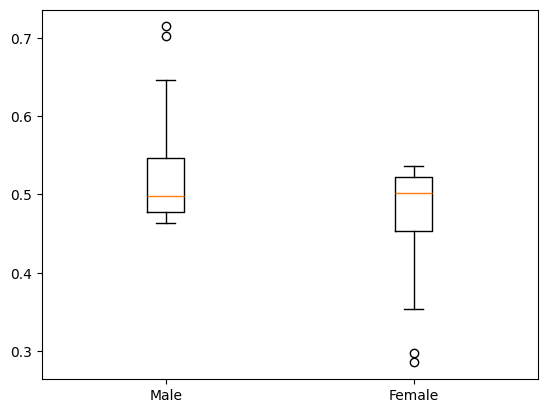

In [ ]:
plt.boxplot([SData['PropMale'], 1 - SData['PropMale']], labels=['Male', 'Female'])
plt.show()

In [ ]:
tscore, pvalue = ttest_1samp(SData["PropMale"], popmean=0.5)
print("T-score:", tscore, "P-value:", pvalue)

T-score: 1.992408085629867 P-value: 0.05692334815203012


In [ ]:
from scipy.stats import ttest_ind

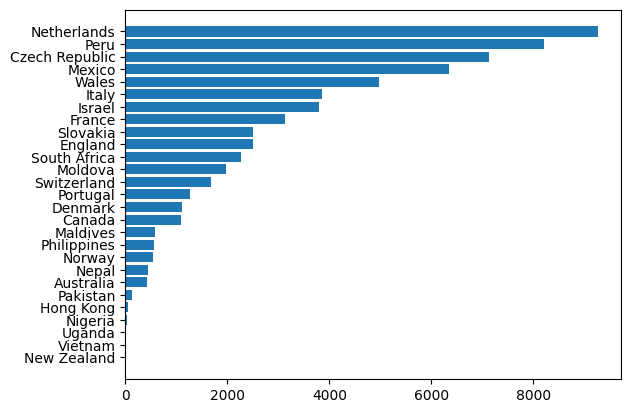

In [ ]:
SData['TotalDeaths'] = SData['DNoMale'] + SData['DNoFemale']
SData_death_sorted = SData.sort_values('TotalDeaths')
plt.barh(SData_death_sorted['place'], SData_death_sorted['TotalDeaths'])
plt.show()

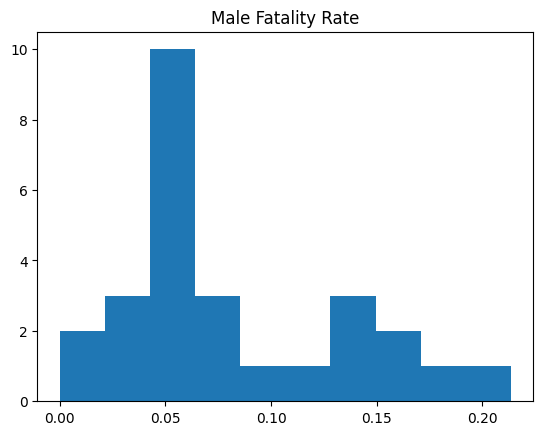

In [ ]:
SData['FatalityMale'] = SData['DNoMale'] / SData['NoMale']
plt.hist(SData['FatalityMale'], bins=10)
plt.title("Male Fatality Rate")
plt.show()

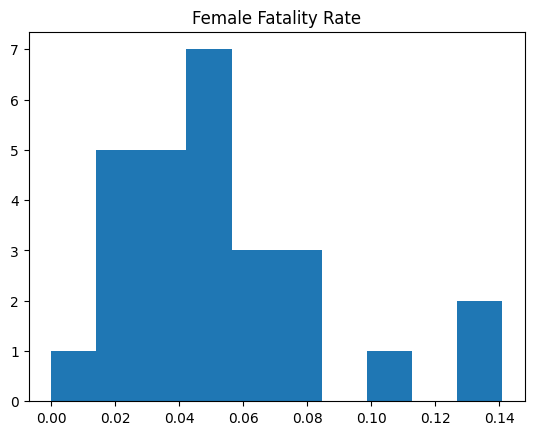

In [ ]:
SData['FatalityFemale'] = SData['DNoFemale'] / SData['NoFemale']
plt.hist(SData['FatalityFemale'], bins=10)
plt.title("Female Fatality Rate")
plt.show()

/tmp/ipython-input-305/1932451017.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([SData['FatalityMale'], SData['FatalityFemale']], labels=['Male', 'Female'])


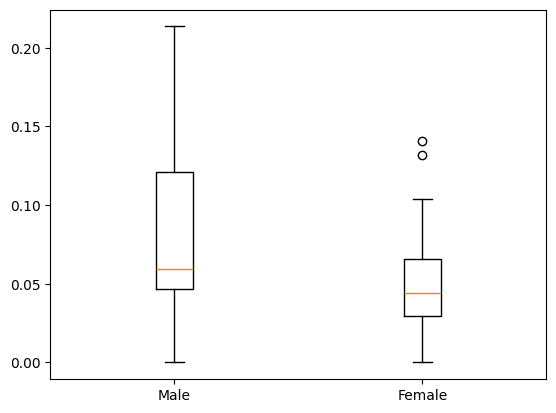

In [ ]:
plt.boxplot([SData['FatalityMale'], SData['FatalityFemale']], labels=['Male', 'Female'])
plt.show()

In [ ]:
t_stat, p_val = ttest_ind(SData['FatalityMale'], SData['FatalityFemale'])
print("Two-sample T-test T-stat:", t_stat, "P-value:", p_val)

Two-sample T-test T-stat: 2.4241182745256866 P-value: 0.018858488897391452
